# Specification Curve Analysis: Bar-Gill, Brynjolfsson & Hak (2024)

**Focal metric:** ITT effect of Seller Hub access on weekly sales (Table 2, Col 1, δ = 0.035)

**Research question:** How sensitive is the estimated treatment effect to the researcher's choice of functional form, fixed effects structure, sample definition, and covariate design?

In [1]:
import pandas as pd
import numpy as np
import pyfixest as pf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import statsmodels.formula.api as smf
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

OUTPUT = Path('output')
OUTPUT.mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
})
sns.set_style('whitegrid')
print('Setup complete.')

Setup complete.


## 1. Data Loading and Variable Construction

In [2]:
# Load raw data
panel_raw = pd.read_csv('../panelCln_noCustID_Sample.csv')
slr_raw   = pd.read_csv('../SlrLvlCln_noCustID_Sample.csv')

# Merge panel with seller-level data
panel = panel_raw.merge(slr_raw, on='ID', how='left')

# Convert dates
panel['WeekEndingDate'] = pd.to_datetime(panel['WeekEndingDate'])
panel['TreatmentDate']  = pd.to_datetime(panel['TreatmentDate'])
panel['OptInDate']      = pd.to_datetime(panel['OptInDate'])

# Treatment indicators
panel['SHaccess']   = (panel['WeekEndingDate'] >= panel['TreatmentDate']).astype(int)
panel['SHadoption'] = (panel['WeekEndingDate'] >= panel['OptInDate']).astype(int)
panel['SHadoption'] = panel['SHadoption'].fillna(0).astype(int)

# Adopt within 1 week
panel['TrtToOptIn'] = (panel['OptInDate'] - panel['TreatmentDate']).dt.days
panel['Adopt1week'] = ((panel['TrtToOptIn'] >= 0) & (panel['TrtToOptIn'] <= 7)).astype(int)

# Outcome variables
panel['Sales']       = panel['GMV'] + 1
panel['Quantity']    = panel['QtySold'] + 1
panel['NewListings'] = panel['numNewListings'] + 1

# Homogeneity indicator
HomogCategories = ['Media', 'Electronics', 'Business & Industrial', 'Parts & Accessories']
panel['Homog'] = panel['MainCategory'].isin(HomogCategories).astype(int)

# FE identifiers
panel['ID_str']  = panel['ID'].astype(str)
panel['WED_str'] = panel['WeekEndingDate'].dt.strftime('%Y-%m-%d')

# RampGroup for cohort-specific trends (D2)
panel['RampGroup'] = panel['TreatmentDate'].dt.strftime('%Y-%m-%d')
ramp_groups = sorted(panel['RampGroup'].unique())
ref_group = ramp_groups[-1]

for g in ramp_groups:
    if g != ref_group:
        col = f'ct_{g.replace("-","")}'
        panel[col] = (panel['RampGroup'] == g).astype(int) * panel['weekIndex']

cohort_trend_cols = [c for c in panel.columns if c.startswith('ct_')]

# Subsamples
panel_pos = panel[panel['GMV'] > 0].copy()
panel_ea  = panel[panel['Adopt1week'] == 1].copy()

print(f'Full sample:     {len(panel):>10,} obs ({panel["ID"].nunique():,} sellers)')
print(f'Positive-sales:  {len(panel_pos):>10,} obs ({panel_pos["ID"].nunique():,} sellers)')
print(f'Early adopters:  {len(panel_ea):>10,} obs ({panel_ea["ID"].nunique():,} sellers)')
print(f'Zero-sales:      {(panel["GMV"]==0).mean():.1%}')
print(f'Cohort trend vars: {cohort_trend_cols}')
print(f'Ramp-up groups: {ramp_groups}')

Full sample:        423,706 obs (18,422 sellers)
Positive-sales:     319,925 obs (17,708 sellers)
Early adopters:      85,514 obs (3,718 sellers)
Zero-sales:      24.5%
Cohort trend vars: ['ct_20160512', 'ct_20160519', 'ct_20160606', 'ct_20160613', 'ct_20160621', 'ct_20160726']
Ramp-up groups: ['2016-05-12', '2016-05-19', '2016-06-06', '2016-06-13', '2016-06-21', '2016-07-26', '2016-08-08']


## 2. Summary Statistics

In [3]:
stats_vars = {
    'GMV': 'Weekly Sales (GMV, $)',
    'QtySold': 'Quantity Sold',
    'Price': 'Price ($)',
    'numNewListings': 'New Listings',
    'Feedback': 'Feedback Score',
    'SHaccess': 'Seller Hub Access',
    'SHadoption': 'Seller Hub Adoption',
}

rows = []
for var, label in stats_vars.items():
    s = panel[var].dropna()
    rows.append({
        'Variable': label,
        'N': len(s),
        'Mean': s.mean(),
        'Std. Dev.': s.std(),
        'Median': s.median(),
        'Min': s.min(),
        'Max': s.max(),
        '% Zero': (s == 0).mean() * 100 if var in ['GMV', 'QtySold', 'numNewListings'] else np.nan,
    })

summary_df = pd.DataFrame(rows)
summary_df.to_csv(OUTPUT / 'summary_stats.csv', index=False, float_format='%.2f')
print(summary_df.to_string(index=False, float_format=lambda x: f'{x:,.2f}'))
print(f'\nSaved to {OUTPUT / "summary_stats.csv"}')

             Variable      N     Mean  Std. Dev.   Median  Min        Max  % Zero
Weekly Sales (GMV, $) 423706   930.70   4,056.35   225.00 0.00 690,211.80   24.49
        Quantity Sold 423706    31.14     162.02     5.00 0.00  12,086.00   24.49
            Price ($) 319925   324.64   1,031.96   136.14 0.01 138,000.00     NaN
         New Listings 423706    20.97     165.51     2.00 0.00  20,858.00   42.96
       Feedback Score 423660 4,817.29  16,878.53 1,172.00 0.00 675,598.90     NaN
    Seller Hub Access 423706     0.23       0.42     0.00 0.00       1.00     NaN
  Seller Hub Adoption 423706     0.07       0.26     0.00 0.00       1.00     NaN

Saved to output/summary_stats.csv


## 3. Specification Curve Engine

In [4]:
FORM_LABELS = {
    'F1': 'log(GMV+1)', 'F2': 'log(GMV/1000+1)', 'F3': '1(GMV>0)',
    'F4': 'log(GMV)|GMV>0', 'F5': 'asinh(GMV)', 'F6': 'GMV levels',
    'F7': 'Poisson PPML',
}
FE_LABELS = {
    'E1': 'Seller+Week FE', 'E2': 'Seller FE only',
    'E3': 'Week FE only', 'E4': 'No FE',
}
SAMPLE_LABELS = {
    'S1': 'Full sample', 'S2': 'Positive-sales', 'S3': 'Early adopters',
}
COV_LABELS = {
    'D1': 'No controls', 'D2': 'Cohort trends',
}


def run_specification(panel_full, panel_pos, panel_ea, cohort_trend_cols,
                      func_form, fe, sample, cov_design):
    """Run a single specification and return results dict."""
    # Select sample
    if sample == 'S2':
        data = panel_pos
    elif sample == 'S3':
        data = panel_ea
    else:
        data = panel_full

    # Construct DV
    data = data.copy()
    is_poisson = False

    if func_form == 'F1':
        data['DV'] = np.log(data['GMV'] + 1)
    elif func_form == 'F2':
        data['DV'] = np.log(data['GMV'] / 1000 + 1)
    elif func_form == 'F3':
        data['DV'] = (data['GMV'] > 0).astype(int)
    elif func_form == 'F4':
        data = data[data['GMV'] > 0].copy()
        data['DV'] = np.log(data['GMV'])
    elif func_form == 'F5':
        data['DV'] = np.arcsinh(data['GMV'])
    elif func_form == 'F6':
        data['DV'] = data['GMV']
    elif func_form == 'F7':
        data['DV'] = data['GMV']
        is_poisson = True

    if len(data) == 0:
        return {'estimate': np.nan, 'se_seller': np.nan, 'se_hc1': np.nan,
                'se_twoway': np.nan, 'n': 0, 'converged': False,
                'error': 'Empty sample'}

    # Build formula
    cov_str = ''
    if cov_design == 'D2' and len(cohort_trend_cols) > 0:
        cov_str = ' + ' + ' + '.join(cohort_trend_cols)

    fe_map = {
        'E1': ' | ID_str + WED_str',
        'E2': ' | ID_str',
        'E3': ' | WED_str',
        'E4': '',
    }
    fe_str = fe_map[fe]
    formula = f'DV ~ SHaccess{cov_str}{fe_str}'

    # Estimate
    try:
        if is_poisson:
            model = pf.fepois(formula, data=data, vcov={'CRV1': 'ID_str'})
            est = model.coef()['SHaccess']
            se1 = model.se()['SHaccess']
            return {'estimate': est, 'se_seller': se1, 'se_hc1': se1,
                    'se_twoway': se1, 'n': int(model._N),
                    'converged': True, 'error': ''}
        else:
            model = pf.feols(formula, data=data, vcov={'CRV1': 'ID_str'})
            est = model.coef()['SHaccess']
            se1 = model.se()['SHaccess']

            try:
                model.vcov('hetero')
                se2 = model.se()['SHaccess']
            except Exception:
                se2 = np.nan

            try:
                model.vcov({'CRV1': 'ID_str+WED_str'})
                se3 = model.se()['SHaccess']
            except Exception:
                se3 = np.nan

            return {'estimate': est, 'se_seller': se1, 'se_hc1': se2,
                    'se_twoway': se3, 'n': int(model._N),
                    'converged': True, 'error': ''}
    except Exception as e:
        return {'estimate': np.nan, 'se_seller': np.nan, 'se_hc1': np.nan,
                'se_twoway': np.nan, 'n': 0, 'converged': False,
                'error': str(e)[:200]}

In [5]:
# Smoke test: baseline spec (F1, E1, S1, D1)
test = run_specification(panel, panel_pos, panel_ea, cohort_trend_cols,
                         'F1', 'E1', 'S1', 'D1')
print(f"Baseline (F1, E1, S1, D1):")
print(f"  δ̂ = {test['estimate']:.4f} (SE = {test['se_seller']:.4f})")
print(f"  N = {test['n']:,}")
print(f"  Converged: {test['converged']}")
print(f"  Paper reports: δ = 0.035 (SE = 0.005)")

Baseline (F1, E1, S1, D1):
  δ̂ = 0.0025 (SE = 0.0172)
  N = 423,706
  Converged: True
  Paper reports: δ = 0.035 (SE = 0.005)


## 4. Main Specification Curve (~140 specifications)

In [6]:
func_forms = ['F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7']
fe_structs = ['E1', 'E2', 'E3', 'E4']
samples    = ['S1', 'S2', 'S3']
cov_designs = ['D1', 'D2']

results = []
skipped = []
total = 0

for ff in func_forms:
    for fe in fe_structs:
        for ss in samples:
            for cd in cov_designs:
                if ff == 'F3' and ss == 'S2':
                    skipped.append((ff, fe, ss, cd, 'Extensive margin undefined on positive-sales'))
                    continue

                total += 1
                res = run_specification(panel, panel_pos, panel_ea,
                                       cohort_trend_cols,
                                       ff, fe, ss, cd)
                res.update({
                    'func_form': ff, 'fe': fe, 'sample': ss, 'cov_design': cd,
                    'form_label': FORM_LABELS[ff],
                    'fe_label': FE_LABELS[fe],
                    'sample_label': SAMPLE_LABELS[ss],
                    'cov_label': COV_LABELS[cd],
                })
                results.append(res)
                if total % 20 == 0:
                    print(f'  ... {total} specifications completed')

specs = pd.DataFrame(results)
n_converged = specs['converged'].sum()
n_failed = (~specs['converged']).sum()

print(f'\nDone: {total} specifications attempted')
print(f'  Converged: {n_converged}')
print(f'  Failed:    {n_failed}')
print(f'  Skipped:   {len(skipped)} (invalid combinations)')
if n_failed > 0:
    print(f'\nFailed specs:')
    for _, row in specs[~specs['converged']].iterrows():
        print(f"  {row['func_form']},{row['fe']},{row['sample']},{row['cov_design']}: {row['error'][:80]}")

  ... 20 specifications completed


  ... 40 specifications completed


  ... 60 specifications completed


  ... 80 specifications completed


  ... 100 specifications completed


  ... 120 specifications completed


  ... 140 specifications completed


  ... 160 specifications completed

Done: 160 specifications attempted
  Converged: 160
  Failed:    0
  Skipped:   8 (invalid combinations)


In [7]:
specs.to_csv(OUTPUT / 'all_specs.csv', index=False, float_format='%.6f')
print(f'Saved {len(specs)} specifications to {OUTPUT / "all_specs.csv"}')

conv = specs[specs['converged']].copy()
print(f'\n── Estimate range (converged specs) ──')
print(f'  Min:    {conv["estimate"].min():.4f}')
print(f'  Median: {conv["estimate"].median():.4f}')
print(f'  Max:    {conv["estimate"].max():.4f}')
print(f'  Sign reversals (δ̂ < 0): {(conv["estimate"] < 0).sum()} / {len(conv)}')

for dim, col in [('Functional Form', 'form_label'), ('FE Structure', 'fe_label'),
                 ('Sample', 'sample_label'), ('Covariate Design', 'cov_label')]:
    print(f'\n── Median estimate by {dim} ──')
    print(conv.groupby(col)['estimate'].median().to_string())

Saved 160 specifications to output/all_specs.csv

── Estimate range (converged specs) ──
  Min:    -124.1792
  Median: -0.0049
  Max:    288.4974
  Sign reversals (δ̂ < 0): 87 / 160

── Median estimate by Functional Form ──
form_label
1(GMV>0)          -0.001754
GMV levels        -9.518284
Poisson PPML      -0.003705
asinh(GMV)        -0.002314
log(GMV)|GMV>0    -0.004560
log(GMV+1)        -0.001554
log(GMV/1000+1)   -0.005175

── Median estimate by FE Structure ──
fe_label
No FE            -0.072315
Seller FE only   -0.036983
Seller+Week FE    0.008099
Week FE only      0.017827

── Median estimate by Sample ──
sample_label
Early adopters    0.003529
Full sample      -0.011280
Positive-sales   -0.002098

── Median estimate by Covariate Design ──
cov_label
Cohort trends   -0.006374
No controls     -0.001601


## 5. Sensitivity to the Choice of c in log(GMV + c)

Chen and Roth (2024) show that log(1+y) estimates depend on the arbitrary constant c. We fix the specification at the authors' baseline (seller + week FE, full sample, no controls) and vary c.

c-sensitivity results (baseline FE, full sample):
          c  estimate       se     ci_lo    ci_hi      n
   0.010000  0.002550 0.029327 -0.054930 0.060030 423706
   0.100000  0.002517 0.023178 -0.042912 0.047946 423706
   1.000000  0.002466 0.017203 -0.031252 0.036184 423706
  10.000000  0.001921 0.011564 -0.020745 0.024587 423706
 100.000000  0.000559 0.006484 -0.012149 0.013268 423706
1000.000000 -0.000225 0.002598 -0.005317 0.004867 423706


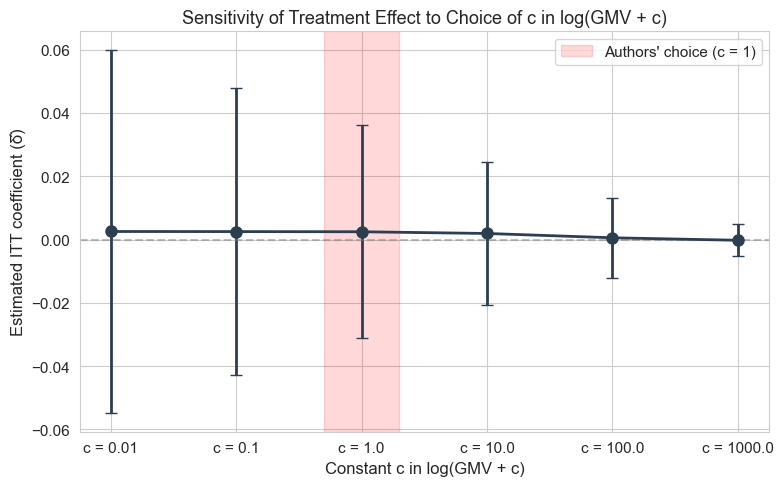

Saved to output/c_sensitivity.png


In [8]:
c_values = [0.01, 0.1, 1, 10, 100, 1000]
c_results = []

for c in c_values:
    data = panel.copy()
    data['DV'] = np.log(data['GMV'] + c)
    try:
        model = pf.feols('DV ~ SHaccess | ID_str + WED_str',
                         data=data, vcov={'CRV1': 'ID_str'})
        est = model.coef()['SHaccess']
        se  = model.se()['SHaccess']
        c_results.append({'c': c, 'estimate': est, 'se': se,
                          'ci_lo': est - 1.96*se, 'ci_hi': est + 1.96*se,
                          'n': int(model._N)})
    except Exception as e:
        c_results.append({'c': c, 'estimate': np.nan, 'se': np.nan,
                          'ci_lo': np.nan, 'ci_hi': np.nan, 'n': 0})

c_df = pd.DataFrame(c_results)
print('c-sensitivity results (baseline FE, full sample):')
print(c_df.to_string(index=False, float_format=lambda x: f'{x:.6f}'))

# Figure
fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(range(len(c_df)), c_df['estimate'],
            yerr=1.96 * c_df['se'],
            fmt='o-', color='#2c3e50', capsize=4, markersize=8, linewidth=2)
ax.set_xticks(range(len(c_df)))
ax.set_xticklabels([f'c = {c}' for c in c_df['c']], fontsize=11)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

authors_idx = list(c_df['c']).index(1)
ax.axvspan(authors_idx - 0.3, authors_idx + 0.3, alpha=0.15, color='red',
           label="Authors' choice (c = 1)")

ax.set_xlabel('Constant c in log(GMV + c)')
ax.set_ylabel('Estimated ITT coefficient (δ̂)')
ax.set_title('Sensitivity of Treatment Effect to Choice of c in log(GMV + c)')
ax.legend(frameon=True)
fig.tight_layout()
fig.savefig(OUTPUT / 'c_sensitivity.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved to {OUTPUT / "c_sensitivity.png"}')

## 6. Alternative Outcome: Quantity Sold

To test whether functional form sensitivity generalizes beyond sales revenue, we replicate the 7 functional forms for quantity sold under the baseline FE structure.

In [9]:
qty_results = []

for ff in func_forms:
    data = panel.copy()
    is_poisson = False

    if ff == 'F1':
        data['DV'] = np.log(data['QtySold'] + 1)
    elif ff == 'F2':
        data['DV'] = np.log(data['QtySold'] / 100 + 1)
    elif ff == 'F3':
        data['DV'] = (data['QtySold'] > 0).astype(int)
    elif ff == 'F4':
        data = data[data['QtySold'] > 0].copy()
        data['DV'] = np.log(data['QtySold'])
    elif ff == 'F5':
        data['DV'] = np.arcsinh(data['QtySold'])
    elif ff == 'F6':
        data['DV'] = data['QtySold']
    elif ff == 'F7':
        data['DV'] = data['QtySold']
        is_poisson = True

    try:
        if is_poisson:
            model = pf.fepois('DV ~ SHaccess | ID_str + WED_str',
                              data=data, vcov={'CRV1': 'ID_str'})
        else:
            model = pf.feols('DV ~ SHaccess | ID_str + WED_str',
                             data=data, vcov={'CRV1': 'ID_str'})
        est = model.coef()['SHaccess']
        se  = model.se()['SHaccess']
        qty_results.append({
            'func_form': ff, 'form_label': FORM_LABELS[ff],
            'estimate': est, 'se': se, 'n': int(model._N),
            'converged': True
        })
    except Exception as e:
        qty_results.append({
            'func_form': ff, 'form_label': FORM_LABELS[ff],
            'estimate': np.nan, 'se': np.nan, 'n': 0,
            'converged': False
        })

qty_df = pd.DataFrame(qty_results)
qty_df.to_csv(OUTPUT / 'quantity_specs.csv', index=False, float_format='%.6f')
print('Quantity specifications (E1, S1, D1):')
print(qty_df[['form_label', 'estimate', 'se', 'n', 'converged']].to_string(index=False))

Quantity specifications (E1, S1, D1):
     form_label  estimate       se      n  converged
     log(GMV+1) -0.002390 0.007589 423706       True
log(GMV/1000+1) -0.001108 0.001238 423706       True
       1(GMV>0)  0.000041 0.002779 423706       True
 log(GMV)|GMV>0 -0.000256 0.007416 319464       True
     asinh(GMV) -0.002816 0.009015 423706       True
     GMV levels -1.543558 0.681715 423706       True
   Poisson PPML -0.037057 0.023315 407284       True


## 7. Meta-Regression

$$\hat{\delta}_k = \gamma_0 + \gamma_F \cdot \text{FuncForm}_k + \gamma_E \cdot \text{FE}_k + \gamma_S \cdot \text{Sample}_k + \gamma_D \cdot \text{CovDesign}_k + u_k$$

In [10]:
meta = specs[specs['converged']].copy()

# Create dummies (baseline = F1, E1, S1, D1)
meta_dummies = pd.get_dummies(meta[['func_form', 'fe', 'sample', 'cov_design']],
                              drop_first=False)

baseline_cols = ['func_form_F1', 'fe_E1', 'sample_S1', 'cov_design_D1']
for col in baseline_cols:
    if col in meta_dummies.columns:
        meta_dummies = meta_dummies.drop(columns=[col])

meta_reg_data = pd.concat([meta[['estimate']].reset_index(drop=True),
                           meta_dummies.reset_index(drop=True)], axis=1)

formula_parts = ' + '.join([c for c in meta_dummies.columns])
meta_model = smf.ols(f'estimate ~ {formula_parts}', data=meta_reg_data).fit(cov_type='HC1')

print(meta_model.summary())

meta_coefs = pd.DataFrame({
    'coefficient': meta_model.params,
    'se': meta_model.bse,
    'pvalue': meta_model.pvalues,
    'ci_lo': meta_model.conf_int()[0],
    'ci_hi': meta_model.conf_int()[1],
})
meta_coefs.to_csv(OUTPUT / 'meta_regression.csv', float_format='%.6f')
print(f'\nR² = {meta_model.rsquared:.3f}')
print(f'Saved to {OUTPUT / "meta_regression.csv"}')

                            OLS Regression Results                            
Dep. Variable:               estimate   R-squared:                       0.069
Model:                            OLS   Adj. R-squared:                 -0.007
Method:                 Least Squares   F-statistic:                    0.8884
Date:                Fri, 17 Apr 2026   Prob (F-statistic):              0.560
Time:                        23:17:07   Log-Likelihood:                -790.68
No. Observations:                 160   AIC:                             1607.
Df Residuals:                     147   BIC:                             1647.
Df Model:                          12                                         
Covariance Type:                  HC1                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 4.42

In [11]:
dimensions = {
    'Functional Form': [c for c in meta_dummies.columns if c.startswith('func_form')],
    'FE Structure':    [c for c in meta_dummies.columns if c.startswith('fe_')],
    'Sample':          [c for c in meta_dummies.columns if c.startswith('sample_')],
    'Covariate Design':[c for c in meta_dummies.columns if c.startswith('cov_design')],
}

r2_full = meta_model.rsquared
print(f'Full model R² = {r2_full:.4f}\n')
print(f'{"Dimension":<22s} {"Partial R²":>10s} {"Share of R²":>12s}')
print('-' * 46)

partial_r2 = {}
for dim_name, dim_cols in dimensions.items():
    remaining = [c for c in meta_dummies.columns if c not in dim_cols]
    if len(remaining) == 0:
        partial = r2_full
    else:
        formula_reduced = 'estimate ~ ' + ' + '.join(remaining)
        m_reduced = smf.ols(formula_reduced, data=meta_reg_data).fit()
        partial = r2_full - m_reduced.rsquared
    partial_r2[dim_name] = partial
    share = partial / r2_full * 100 if r2_full > 0 else 0
    print(f'{dim_name:<22s} {partial:>10.4f} {share:>11.1f}%')

Full model R² = 0.0694

Dimension              Partial R²  Share of R²
----------------------------------------------
Functional Form            0.0009         1.2%
FE Structure               0.0429        61.8%
Sample                     0.0054         7.8%
Covariate Design           0.0202        29.1%


## 8. Specification Curve Figure

Note: F6 (GMV in levels) produces estimates in dollars rather than log-scale semi-elasticities, creating extreme values (range: -124 to +289). The main figure excludes F6 to show the detail of the 136 comparable log-scale specifications. F6 results are retained in the CSV and meta-regression.

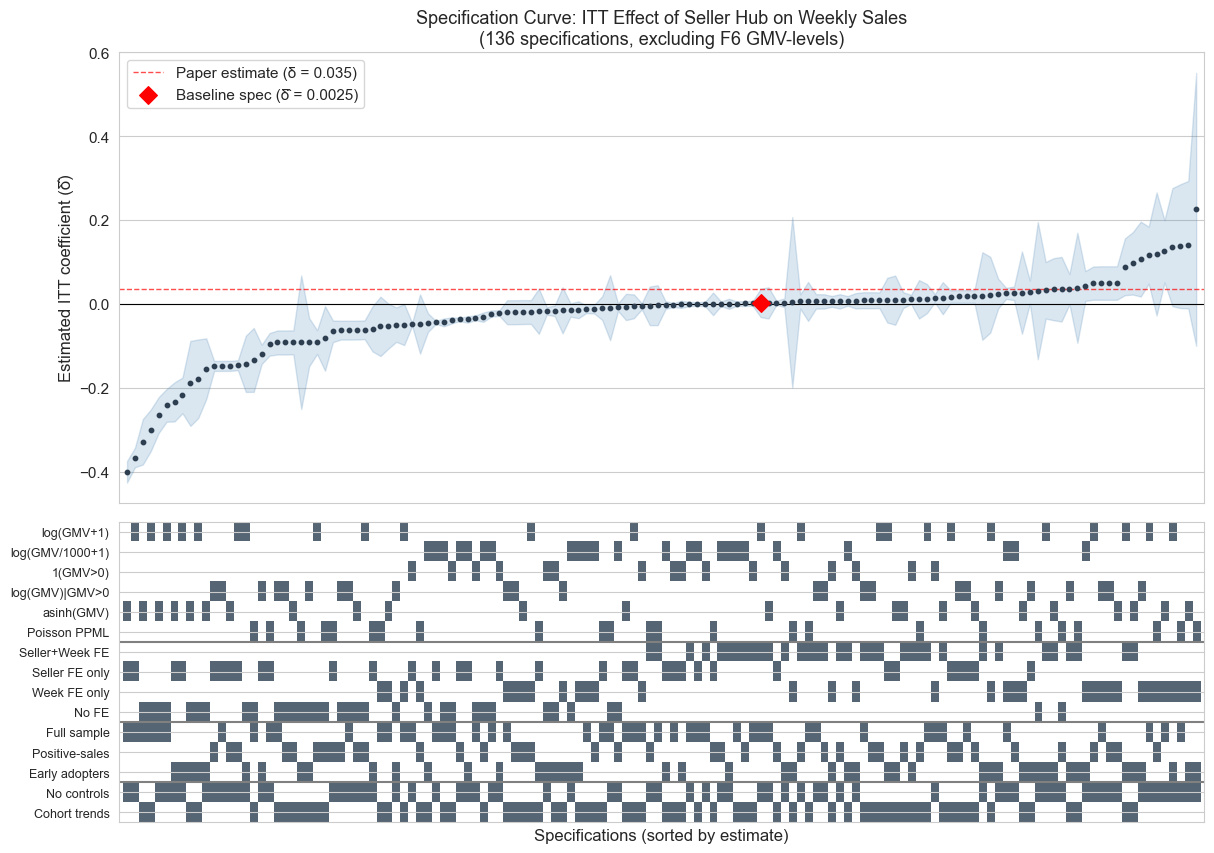

Saved to output/spec_curve.png


In [12]:
# Exclude F6 (GMV levels) — different scale (dollars vs semi-elasticities)
conv = specs[(specs['converged']) & (specs['func_form'] != 'F6')].copy()
conv = conv.sort_values('estimate').reset_index(drop=True)
conv['spec_id'] = range(len(conv))

# Functional forms for indicator matrix (exclude F6)
plot_forms = ['F1', 'F2', 'F3', 'F4', 'F5', 'F7']

fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(2, 1, height_ratios=[3, 2], hspace=0.05)

# ── Top panel: estimates with CIs ─────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])

ax1.fill_between(conv['spec_id'],
                 conv['estimate'] - 1.96 * conv['se_seller'],
                 conv['estimate'] + 1.96 * conv['se_seller'],
                 alpha=0.2, color='steelblue')
ax1.scatter(conv['spec_id'], conv['estimate'], s=10, color='#2c3e50', zorder=3)

ax1.axhline(y=0, color='black', linewidth=0.8, linestyle='-')
ax1.axhline(y=0.035, color='red', linewidth=1, linestyle='--', alpha=0.7,
            label='Paper estimate (δ = 0.035)')

# Highlight baseline spec
baseline_mask = ((conv['func_form'] == 'F1') & (conv['fe'] == 'E1') &
                 (conv['sample'] == 'S1') & (conv['cov_design'] == 'D1'))
if baseline_mask.any():
    bx = conv.loc[baseline_mask, 'spec_id'].values[0]
    by = conv.loc[baseline_mask, 'estimate'].values[0]
    ax1.scatter([bx], [by], s=80, color='red', zorder=5, marker='D',
               label=f'Baseline spec (δ̂ = {by:.4f})')

ax1.set_ylabel('Estimated ITT coefficient (δ̂)')
ax1.legend(loc='upper left', frameon=True)
ax1.set_xlim(-1, len(conv))
ax1.set_xticks([])
ax1.set_title('Specification Curve: ITT Effect of Seller Hub on Weekly Sales\n'
              '(136 specifications, excluding F6 GMV-levels)')

# ── Bottom panel: indicator matrix ────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1], sharex=ax1)

indicator_rows = []
indicator_labels = []

for ff in plot_forms:
    indicator_rows.append((conv['func_form'] == ff).astype(int).values)
    indicator_labels.append(FORM_LABELS[ff])
for fe in fe_structs:
    indicator_rows.append((conv['fe'] == fe).astype(int).values)
    indicator_labels.append(FE_LABELS[fe])
for ss in samples:
    indicator_rows.append((conv['sample'] == ss).astype(int).values)
    indicator_labels.append(SAMPLE_LABELS[ss])
for cd in cov_designs:
    indicator_rows.append((conv['cov_design'] == cd).astype(int).values)
    indicator_labels.append(COV_LABELS[cd])

indicator_matrix = np.array(indicator_rows)

cmap = plt.cm.colors.ListedColormap(['white', '#2c3e50'])
ax2.imshow(indicator_matrix, aspect='auto', cmap=cmap, interpolation='none', alpha=0.8)
ax2.set_yticks(range(len(indicator_labels)))
ax2.set_yticklabels(indicator_labels, fontsize=9)
ax2.set_xlabel('Specifications (sorted by estimate)')

# Separators: after forms (6), FE (4), samples (3)
sep_positions = [5.5, 9.5, 12.5]
for sp in sep_positions:
    ax2.axhline(y=sp, color='gray', linewidth=1.5, linestyle='-')

fig.savefig(OUTPUT / 'spec_curve.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved to {OUTPUT / "spec_curve.png"}')

In [13]:
conv = specs[specs['converged']].copy()
print('Significance of δ̂ under different SE methods:')
print(f'{"Clustering":<25s} {"Sig at 5%":>10s} {"Sig at 10%":>10s} {"Total":>8s}')
print('-' * 55)

for se_col, label in [('se_seller', 'Seller-clustered'),
                       ('se_hc1', 'HC1'),
                       ('se_twoway', 'Two-way (seller+week)')]:
    valid = conv[conv[se_col].notna()]
    t_stat = valid['estimate'].abs() / valid[se_col]
    sig5  = (t_stat > 1.96).sum()
    sig10 = (t_stat > 1.645).sum()
    print(f'{label:<25s} {sig5:>6} / {len(valid):<4} {sig10:>6} / {len(valid):<4} {len(valid):>8}')

Significance of δ̂ under different SE methods:
Clustering                 Sig at 5% Sig at 10%    Total
-------------------------------------------------------
Seller-clustered              72 / 160      80 / 160       160
HC1                           82 / 160      86 / 160       160
Two-way (seller+week)         74 / 160      85 / 160       160


## 9. Summary and Export

All results exported to `output/`:
- `all_specs.csv` — Full specification curve results (~160 specifications)
- `meta_regression.csv` — Meta-regression coefficients
- `summary_stats.csv` — Summary statistics
- `quantity_specs.csv` — Quantity outcome supplementary results
- `spec_curve.png` — Main specification curve figure
- `c_sensitivity.png` — c-sensitivity figure

In [14]:
print('=' * 60)
print('EXTENSION ANALYSIS COMPLETE')
print('=' * 60)
conv = specs[specs['converged']]
print(f'\nSpecifications run:     {len(specs)}')
print(f'Converged:             {conv.shape[0]}')
print(f'Failed:                {(~specs["converged"]).sum()}')
print(f'\nEstimate range:        [{conv["estimate"].min():.4f}, {conv["estimate"].max():.4f}]')
print(f'Median estimate:       {conv["estimate"].median():.4f}')
print(f'Paper baseline:        0.035')
print(f'\nMeta-regression R²:    {meta_model.rsquared:.4f}')
print(f'\nOutput files:')
for f in sorted(OUTPUT.glob('*')):
    print(f'  {f.name:30s} ({f.stat().st_size/1024:.1f} KB)')

EXTENSION ANALYSIS COMPLETE

Specifications run:     160
Converged:             160
Failed:                0

Estimate range:        [-124.1792, 288.4974]
Median estimate:       -0.0049
Paper baseline:        0.035

Meta-regression R²:    0.0694

Output files:
  all_specs.csv                  (17.9 KB)
  c_sensitivity.png              (115.9 KB)
  c_sensitivity_preview.png      (129.5 KB)
  meta_regression.csv            (0.9 KB)
  quantity_specs.csv             (0.4 KB)
  spec_curve.png                 (408.1 KB)
  spec_curve_preview.png         (224.8 KB)
  summary_stats.csv              (0.5 KB)
